<a href="https://colab.research.google.com/github/marcelcerri/Python_biocientistas_unesp/blob/main/Aula_05_importando_dados_ajuste.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tratamento de Dados e Regressão Linear

Iniciando o processamento dos dados...

--- Resultados da Modelagem ---
Coeficiente angular: 0.9893
Coeficiente linear: 0.8280
Coeficiente de determinação (R²): 0.9955


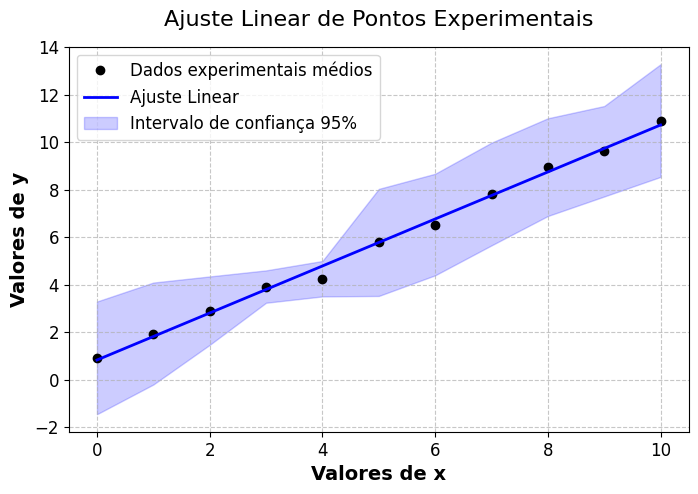


Processamento concluído com sucesso!
-> Gráfico salvo como "Linearizacao_com_media_otimizada.png".
-> Dados exportados para "Saida_de_dados_linear_media.xlsx".


In [3]:
# -*- coding: utf-8 -*-
"""
Script para Processamento, Modelagem e Visualização de Dados Experimentais.

Este script realiza as seguintes operações:
1. Importa dados experimentais do arquivo 'media_desvio_dados.xlsx'.
2. Realiza o tratamento estatístico (cálculo de média, desvio padrão amostral e
   intervalo de confiança de 95% usando distribuição t de Student).
3. Ajusta um modelo de regressão linear aos dados médios.
4. Calcula a qualidade do ajuste (Coeficiente de Determinação R²).
5. Gera e salva um gráfico da modelagem com o intervalo de confiança sombreado.
6. Exporta os resultados calculados para uma nova planilha Excel.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ==========================================
# 1. IMPORTAÇÃO E TRATAMENTO DE DADOS
# ==========================================
print("Iniciando o processamento dos dados...")

# Carrega os dados do Excel
try:
    df_importado = pd.read_excel("media_desvio_dados.xlsx")
except FileNotFoundError:
    print("Erro: O arquivo 'media_desvio_dados.xlsx' não foi encontrado na pasta.")
    exit()

# Separa a variável independente (x) e as variáveis dependentes (réplicas de y)
# O comando .astype(float) garante que os dados sejam lidos como números,
# evitando erros caso alguma célula do Excel tenha sido preenchida como texto.
x = df_importado.iloc[:, 0].values.astype(float)
Y_replicas = df_importado.iloc[:, 1:4].values.astype(float)

# Calcula a média e o desvio padrão amostral (ddof=1) por linha (axis=1)
y_media = np.mean(Y_replicas, axis=1)
y_std = np.std(Y_replicas, axis=1, ddof=1)

# Trava de Segurança: Se as triplicatas forem idênticas, o desvio padrão será 0.
# Isso gera um erro na estatística que impede o desenho do intervalo no gráfico.
# Substituímos o 0 por um valor minúsculo (1e-9) para manter o cálculo matematicamente viável.
y_std = np.where(y_std == 0, 1e-9, y_std)

# Calcula o Intervalo de Confiança de 95% usando a distribuição t de Student
graus_liberdade = Y_replicas.shape[1] - 1  # n - 1 (para triplicata, df = 2)
conf_int = stats.t.interval(0.95, df=graus_liberdade, loc=y_media, scale=y_std)

# Separa os limites do intervalo de confiança
limite_inferior = np.array(conf_int[0])
limite_superior = np.array(conf_int[1])


# ==========================================
# 2. MODELAGEM MATEMÁTICA (REGRESSÃO LINEAR)
# ==========================================
# Ajusta um polinômio de grau 1 (reta) aos dados médios
modelo_linear = np.polyfit(x, y_media, 1)
coef_angular = modelo_linear[0]
coef_linear = modelo_linear[1]

# Calcula os valores preditos pelo modelo para traçar a reta
modelo_y = np.polyval(modelo_linear, x)

# Estimativa do coeficiente de determinação (R²)
y_residuo = y_media - modelo_y
SQresid = np.sum(y_residuo**2)
y_total = y_media - np.mean(y_media)
SQtotal = np.sum(y_total**2)
R2 = 1 - (SQresid / SQtotal)

# Impressão dos resultados no console
print('\n--- Resultados da Modelagem ---')
print(f'Coeficiente angular: {coef_angular:.4f}')
print(f'Coeficiente linear: {coef_linear:.4f}')
print(f'Coeficiente de determinação (R²): {R2:.4f}')


# ==========================================
# 3. VISUALIZAÇÃO GRÁFICA
# ==========================================
# Configuração global de tamanho das fontes
plt.rc('font', size=14)
plt.rc('axes', titlesize=16, labelsize=14)
plt.rc('xtick', labelsize=12)
plt.rc('ytick', labelsize=12)
plt.rc('legend', fontsize=12)

# Criação da figura e dos eixos usando sintaxe moderna
fig, ax = plt.subplots(figsize=(8, 5))

# Plotagem
ax.plot(x, y_media, 'o', label='Dados experimentais médios', color='black')
ax.plot(x, modelo_y, '-', linewidth=2, label='Ajuste Linear', color='blue')

# Sombreamento do intervalo de confiança
ax.fill_between(x, limite_inferior, limite_superior, color='blue', alpha=0.2,
                label='Intervalo de confiança 95%')

# Formatação do gráfico
ax.set_title("Ajuste Linear de Pontos Experimentais", pad=15)
ax.set_xlabel('Valores de x', weight='bold')
ax.set_ylabel('Valores de y', weight='bold')
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend(loc='best')

# Configurações de fundo e salvamento
fig.patch.set_facecolor('white')
plt.savefig('Linearizacao_com_media_otimizada.png', dpi=400, bbox_inches='tight')
plt.show()


# ==========================================
# 4. EXPORTAÇÃO DOS DADOS
# ==========================================
# Organiza os resultados num DataFrame estruturado
df_resultados = pd.DataFrame({
    'Valores_X': x,
    'Media_Y_Experimental': y_media,
    'Modelo_Y_Predito': modelo_y,
    'Limite_Inf_IC95': limite_inferior,
    'Limite_Sup_IC95': limite_superior,
    'Coeficiente_Angular': coef_angular,
    'Coeficiente_Linear': coef_linear
})

# Exporta para Excel (sem a coluna de índice do Pandas)
# Nota: O bloco 'with' encerra e salva o arquivo automaticamente nas versões novas do Pandas.
arquivo_saida = 'Saida_de_dados_linear_media.xlsx'
with pd.ExcelWriter(arquivo_saida) as writer:
    df_resultados.to_excel(writer, sheet_name="Output_concent", index=False)

print(f'\nProcessamento concluído com sucesso!')
print(f'-> Gráfico salvo como "Linearizacao_com_media_otimizada.png".')
print(f'-> Dados exportados para "{arquivo_saida}".')

# Parte 2 - Modelagem de coeficiente volumétrico de transferência de oxigênio.

<>:77: SyntaxWarning: invalid escape sequence '\p'
<>:81: SyntaxWarning: invalid escape sequence '\c'
<>:77: SyntaxWarning: invalid escape sequence '\p'
<>:81: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_669/508322131.py:77: SyntaxWarning: invalid escape sequence '\p'
  capsize=5, capthick=1.5, label='Dados Experimentais (Média $\pm$ IC 95%)')
/tmp/ipykernel_669/508322131.py:81: SyntaxWarning: invalid escape sequence '\c'
  label=f'Modelo: $k_La = {a_pot:.4f} \cdot N^{{{b_pot:.2f}}}$')


Iniciando a leitura dos dados...

Parâmetros Otimizados: kLa = 0.5360 * N^0.7798
Coeficiente de Determinação (R²): 0.9989


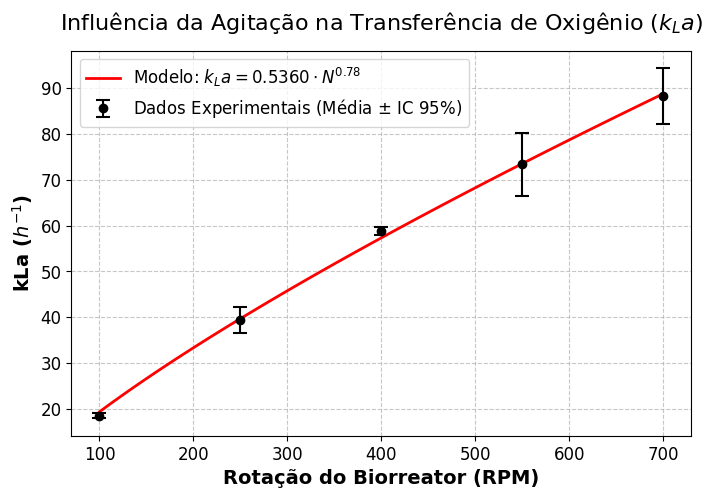


Processamento concluído. Gráfico salvo e planilha exportada.


In [7]:
# -*- coding: utf-8 -*-
"""
Gabarito: Modelagem não-linear do kLa em função da Rotação usando curve_fit
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import curve_fit

# ==========================================
# 1. IMPORTAÇÃO E TRATAMENTO ESTATÍSTICO
# ==========================================
print("Iniciando a leitura dos dados...")
try:
    df_importado = pd.read_excel("dados_kla.xlsx")
except FileNotFoundError:
    print("Erro: Arquivo 'dados_kla.xlsx' não encontrado.")
    exit()

# Extraindo X (RPM) e Y (Réplicas de kLa)
x_rpm = df_importado.iloc[:, 0].values.astype(float)
Y_reps = df_importado.iloc[:, 1:5].values.astype(float)

# Estatística descritiva
y_media = np.mean(Y_reps, axis=1)
y_std = np.std(Y_reps, axis=1, ddof=1)
y_std = np.where(y_std == 0, 1e-9, y_std)

# Intervalo de Confiança (Barra de erro da Média)
n_replicas = Y_reps.shape[1]
graus_lib = n_replicas - 1

# Erro padrão da média = std / sqrt(n)
ic_inf, ic_sup = stats.t.interval(0.95, df=graus_lib, loc=y_media, scale=y_std/np.sqrt(n_replicas))

# Tamanho numérico da barra de erro (distância da média até o limite)
erro_ic = ic_sup - y_media


# ==========================================
# 2. MODELAGEM MATEMÁTICA (CURVE_FIT)
# ==========================================
# Passo A: Definir a função matemática do modelo
def modelo_potencia(N, a, b):
    return a * (N ** b)

# Passo B: Ajustar o modelo aos dados experimentais médios
# p0 é o chute inicial para [a, b]. Ajuda o algoritmo a convergir mais rápido.
parametros_otimizados, matriz_covariancia = curve_fit(modelo_potencia, x_rpm, y_media, p0=[0.01, 1.0])

a_pot = parametros_otimizados[0]
b_pot = parametros_otimizados[1]

# Para traçar uma curva contínua no gráfico
x_curva = np.linspace(min(x_rpm), max(x_rpm), 100)
y_curva = modelo_potencia(x_curva, a_pot, b_pot)

# Calculando R2
y_modelo_pontos = modelo_potencia(x_rpm, a_pot, b_pot)
SQresid = np.sum((y_media - y_modelo_pontos)**2)
SQtotal = np.sum((y_media - np.mean(y_media))**2)
R2 = 1 - (SQresid / SQtotal)

print(f'\nParâmetros Otimizados: kLa = {a_pot:.4f} * N^{b_pot:.4f}')
print(f'Coeficiente de Determinação (R²): {R2:.4f}')


# ==========================================
# 3. VISUALIZAÇÃO GRÁFICA (Com Barras de Erro)
# ==========================================
plt.rc('font', size=14)
fig, ax = plt.subplots(figsize=(8, 5))

# Plotando os dados com barras de erro verticais
ax.errorbar(x_rpm, y_media, yerr=erro_ic, fmt='o', color='black',
            capsize=5, capthick=1.5, label='Dados Experimentais (Média $\pm$ IC 95%)')

# Plotando a curva contínua do modelo ajustado
ax.plot(x_curva, y_curva, '-', color='red', linewidth=2,
        label=f'Modelo: $k_La = {a_pot:.4f} \cdot N^{{{b_pot:.2f}}}$')

ax.set_title("Influência da Agitação na Transferência de Oxigênio ($k_L a$)", pad=15)
ax.set_xlabel('Rotação do Biorreator (RPM)', weight='bold')
ax.set_ylabel('kLa ($h^{-1}$)', weight='bold')
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend(loc='best')
fig.patch.set_facecolor('white')
plt.savefig('Modelo_kLa_CurveFit.png', dpi=400, bbox_inches='tight')
plt.show()


# ==========================================
# 4. EXPORTAÇÃO DOS DADOS
# ==========================================
df_resultados = pd.DataFrame({
    'Rotacao_RPM': x_rpm,
    'kLa_Medio': y_media,
    'kLa_Predito': y_modelo_pontos,
    'Limite_Inf_IC95': ic_inf,
    'Limite_Sup_IC95': ic_sup
})

with pd.ExcelWriter('Saida_dados_kLa_CurveFit.xlsx') as writer:
    df_resultados.to_excel(writer, sheet_name="Resultados_kLa", index=False)

print("\nProcessamento concluído. Gráfico salvo e planilha exportada.")